In [235]:
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import statsmodels.tsa.stattools as sm
%matplotlib inline

# In sample 

In [236]:
TIME = "10y"
START = "2016-01-01"
END = "2024-01-01"
PRICE = "Close"
THRESHOLD = 1.43
TRANSACTION_PRICE = 0.05

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


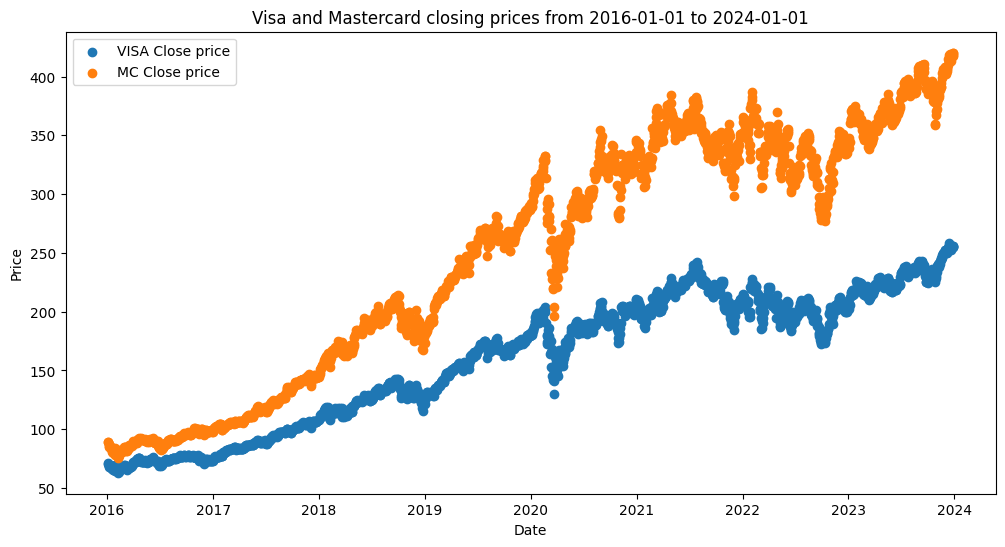

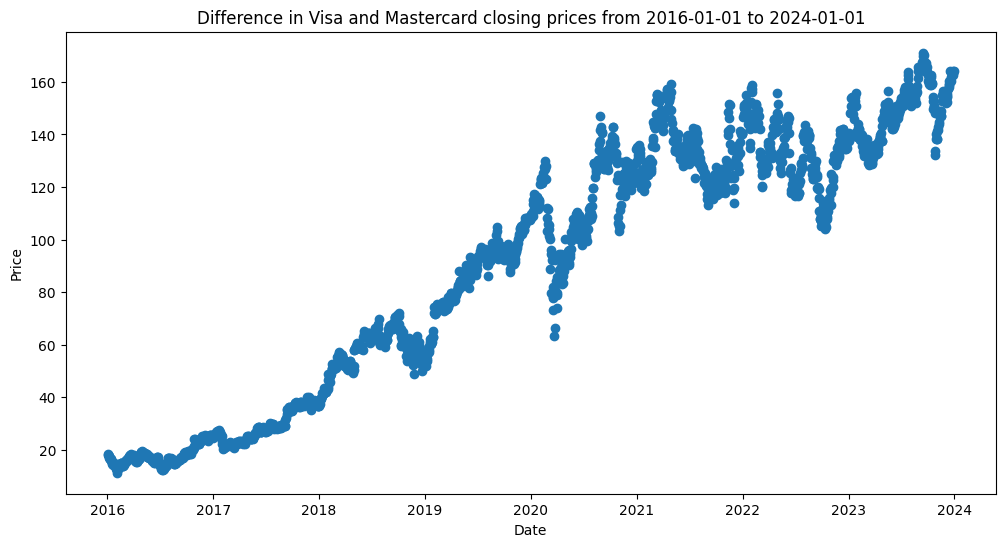

(2012, 1)

In [237]:
visa_data = yf.download("V", start=START, end=END)
mc_data = yf.download("MA", start=START, end=END)

time_data = visa_data.index

plt.figure(figsize=(12, 6))
plt.scatter(time_data, visa_data[PRICE], label=f"VISA {PRICE} price")
plt.scatter(time_data, mc_data[PRICE], label=f"MC {PRICE} price")
plt.title(f"Visa and Mastercard closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(time_data, (mc_data[PRICE].values.flatten() - visa_data[PRICE].values.flatten()), label="Difference")
plt.title(f"Difference in Visa and Mastercard closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

visa_data[PRICE].shape

## Coint tests

In [238]:
_, p_value, _ = sm.coint(visa_data[PRICE].values.flatten(), mc_data[PRICE].values.flatten())
print(f"Cointegration p-value: {p_value:.10f}")

Cointegration p-value: 0.0000175049


## Trading

In [239]:
params = np.polyfit(visa_data[PRICE].values.flatten(), mc_data[PRICE].values.flatten(), deg=1)

print(params)

[  1.8544866  -46.90440871]


[]

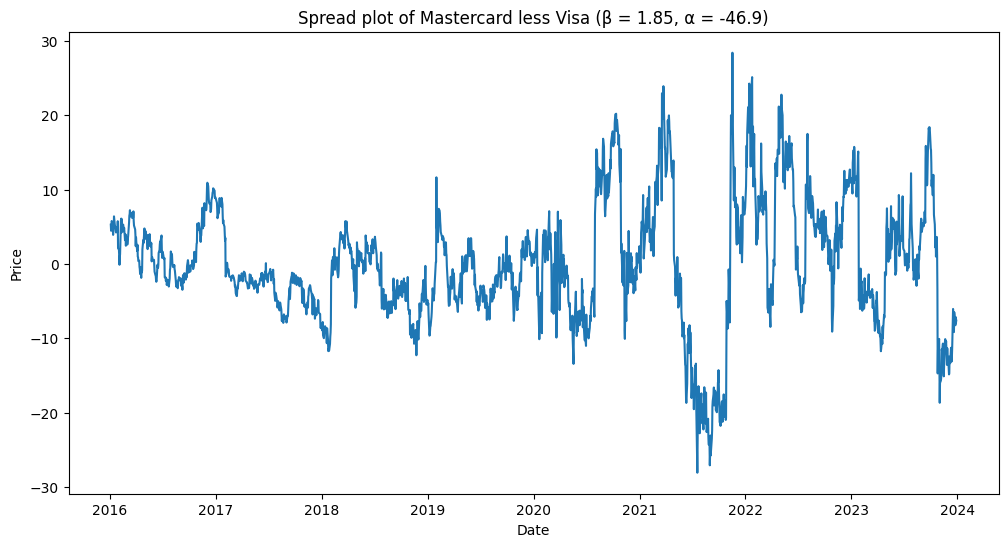

In [240]:
spread = mc_data[PRICE].values.flatten() - params[0]*visa_data[PRICE].values.flatten() - params[1]

plt.figure(figsize=(12, 6))
plt.plot(time_data, spread, label="Spread")
plt.title(f"Spread plot of Mastercard less Visa (\u03B2 = {round(params[0], 2)}, \u03b1 = {round(params[1], 2)})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.plot()

-2.0115563732055323e-14 8.165628665502126


[]

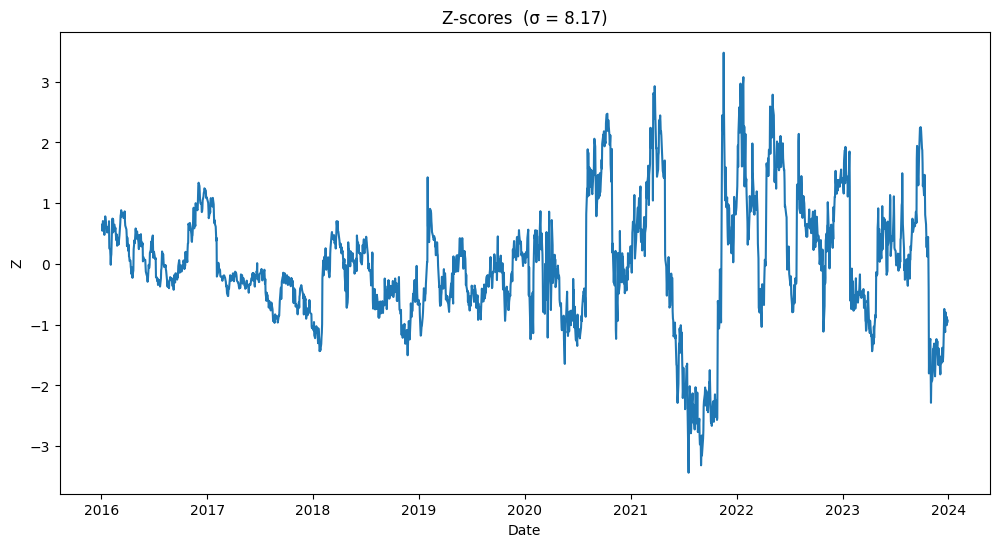

In [241]:
print(np.mean(spread), np.std(spread))

sigma = np.std(spread)

z_scores = spread / sigma

plt.figure(figsize=(12, 6))
plt.plot(time_data, z_scores, label="Spread")
plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)})")
plt.xlabel("Date")
plt.ylabel("Z")
plt.plot()

In [242]:
def signal(z, threshold):
    if z > threshold: return -1 # Short the spread
    elif z < -threshold: return 1 # Long the spread
    return 0 # Flat

signals = list(map(lambda z: signal(z, threshold=THRESHOLD), z_scores))

# plt.figure(figsize=(12, 6))
# plt.plot(time_data, z_scores, label="Z scores")
# plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)})")
# plt.xlabel("Date")
# plt.ylabel("Z")
# plt.plot()


[]

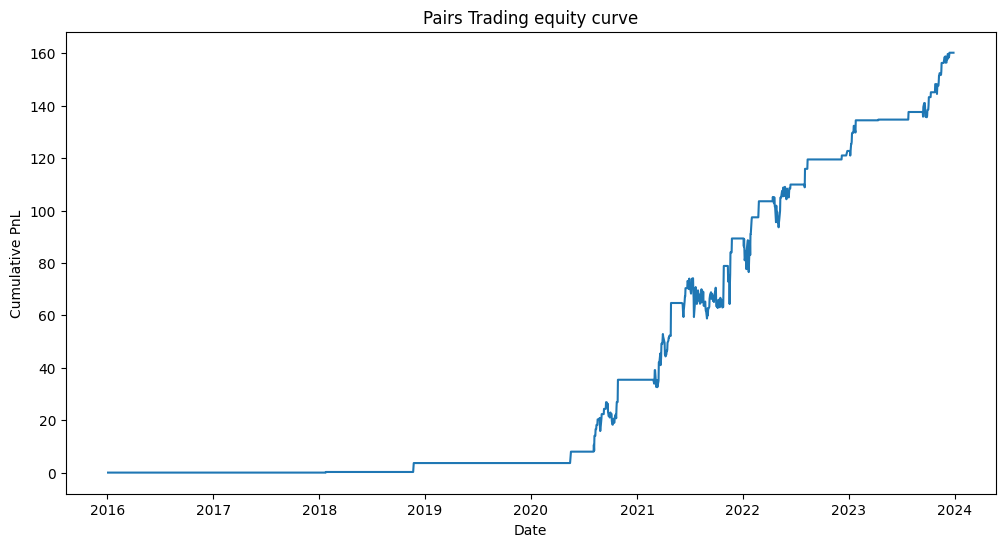

In [243]:
PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE)

plt.figure(figsize=(12, 6))
plt.plot(time_data[:-1], np.cumsum(PnL))
plt.title(f"Pairs Trading equity curve")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot()


In [244]:
print(np.mean(PnL) / np.std(PnL) * np.sqrt(252))

1.1275709986462898


0.54


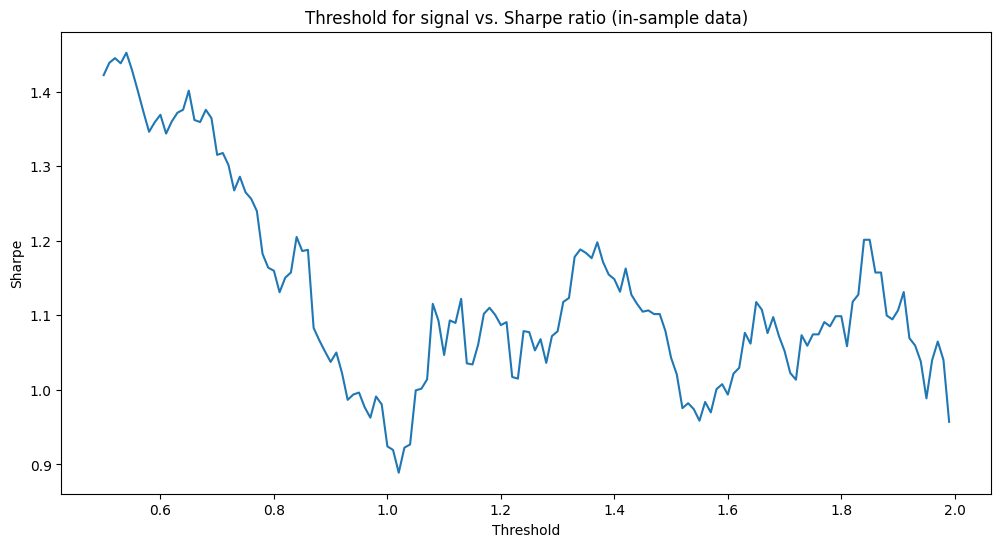

In [245]:
ts = []
sharpes = []

for t in range(50, 200, 1):
    ts.append(t/100)
    signals = list(map(lambda e: signal(e, threshold=t/100), z_scores))
    PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(PnL) / np.std(PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (in-sample data)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot()

print(ts[np.argmax(sharpes)])

# Out of sample (2024-)

In [246]:
visa_test_data = yf.download("V", start=END, end=None)
mc_test_data = yf.download("MA", start=END, end=None)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [247]:
_, p_value, _ = sm.coint(visa_test_data[PRICE].values.flatten(), mc_test_data[PRICE].values.flatten())
print(f"Cointegration p-value: {p_value:.10f}")

Cointegration p-value: 0.2769571725


[]

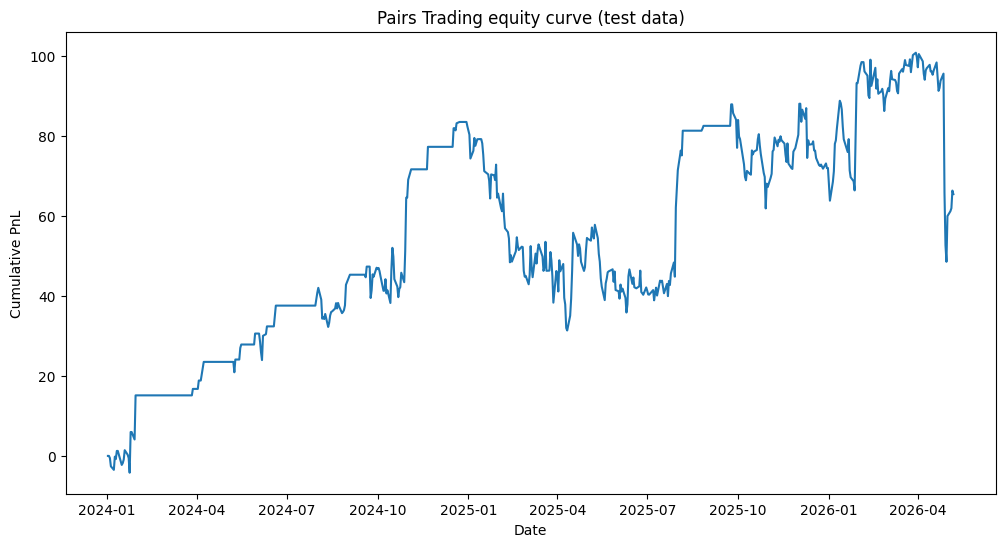

In [248]:
test_time_data = mc_test_data.index

test_spread = mc_test_data[PRICE].values.flatten() - params[0] * visa_test_data[PRICE].values.flatten() - params[1]

test_z_scores = test_spread / sigma

test_signals = list(map(lambda e: signal(e, threshold=THRESHOLD), test_z_scores))

test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)

plt.figure(figsize=(12, 6))
plt.plot(test_time_data[:-1], np.cumsum(test_PnL))
plt.title(f"Pairs Trading equity curve (test data)")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot()

In [249]:
print(np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252))

0.5343279325982883


1.43


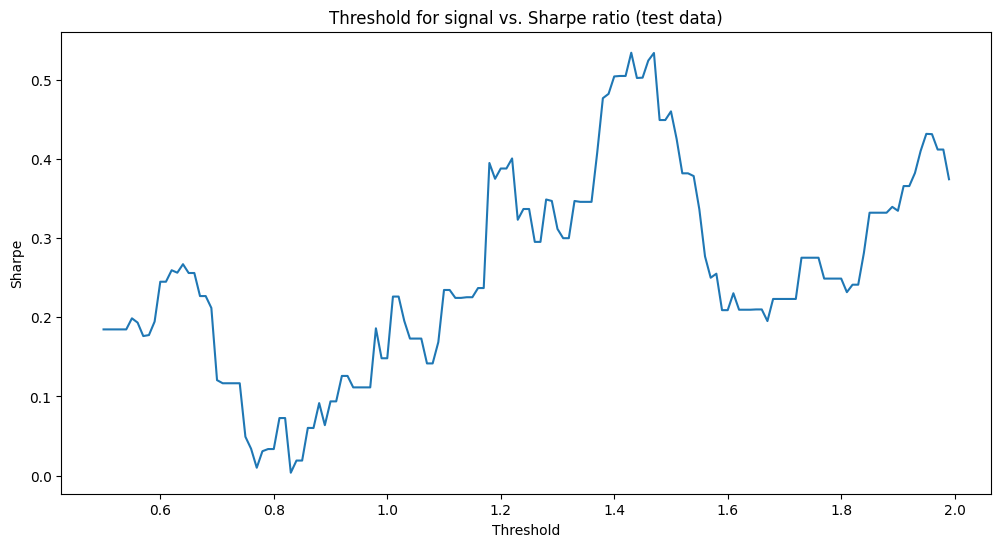

In [250]:
ts = []
sharpes = []

for t in range(50, 200, 1):
    ts.append(t/100)
    test_signals = list(map(lambda e: signal(e, threshold=t/100), test_z_scores))
    test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (test data)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot()

print(ts[np.argmax(sharpes)])
